<a href="https://colab.research.google.com/github/AnjaliAleti/Aleti_INFO5731_Fall2024/blob/main/Aleti_Anjali_Assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


1. Dataset Collection & Preparation


In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving sentiment140.csv to sentiment140.csv


In [ ]:
import pandas as pd

df = pd.read_csv("sentiment140.csv", encoding='latin-1')
print(df.shape)
df.head()

(1599999, 6)


,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
print(df.shape)
df.head()

(1599999, 6)


,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
df = pd.read_csv(
    "sentiment140.csv",
    encoding="latin-1",
    header=None
)

df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df = df[['sentiment', 'text']]

df.head()

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df['sentiment'] = df['sentiment'].replace({0: 'negative', 4: 'positive'})

df['sentiment'].value_counts()

,count
sentiment,
negative,800000
positive,800000


sentiment
negative    800000
positive    800000
Name: count, dtype: int64


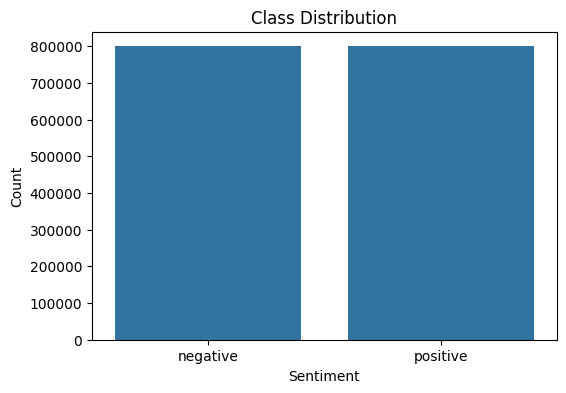

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = df['sentiment'].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
positive_df = df[df['sentiment'] == 'positive'].sample(50000, random_state=42)
negative_df = df[df['sentiment'] == 'negative'].sample(50000, random_state=42)

df_sample = pd.concat([positive_df, negative_df])
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

df_sample.shape

(100000, 2)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# download once
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# use them
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

df_sample['clean_text'] = df_sample['text'].apply(clean_text)

df_sample.head()

,sentiment,text,clean_text
0,negative,says sad to say pero makakabukas lng me ng pc ...,say sad say pero makakabukas lng ng pc tuwing ...
1,negative,Allergies suck ducks nuts. &lt;=====8@8===...,allergy suck duck nut ltgt
2,positive,@jordanknight U 5 guys could be standing in th...,u guy could standing north pole would still ho...
3,negative,Just went through some of my niece's clothes f...,went niece clothes newborn seems like yesterda...
4,negative,"maybe i should take up drinking again, feel as...",maybe take drinking feel massive hangover stil...


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

df_sample['clean_text'] = df_sample['text'].apply(clean_text)

df_sample.head()

,sentiment,text,clean_text
0,negative,says sad to say pero makakabukas lng me ng pc ...,say sad say pero makakabukas lng ng pc tuwing ...
1,negative,Allergies suck ducks nuts. &lt;=====8@8===...,allergy suck duck nut ltgt
2,positive,@jordanknight U 5 guys could be standing in th...,u guy could standing north pole would still ho...
3,negative,Just went through some of my niece's clothes f...,went niece clothes newborn seems like yesterda...
4,negative,"maybe i should take up drinking again, feel as...",maybe take drinking feel massive hangover stil...


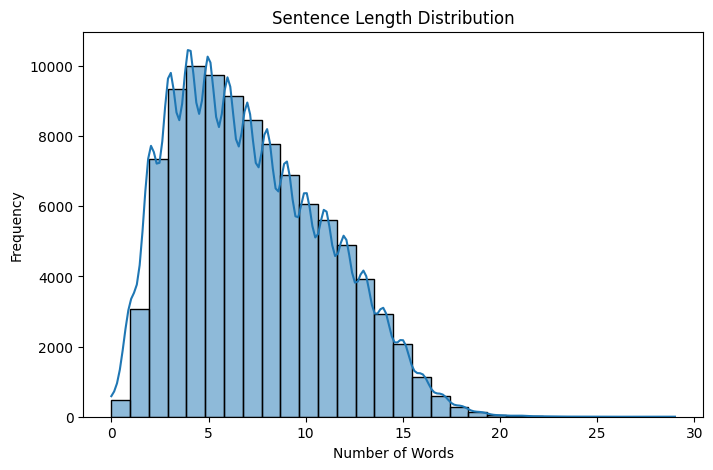

In [ ]:
df_sample['sentence_length'] = df_sample['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df_sample['sentence_length'], bins=30, kde=True)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

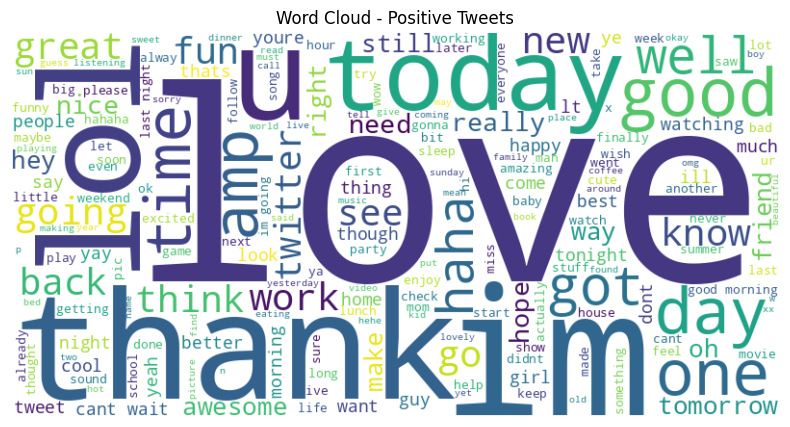

In [ ]:
from wordcloud import WordCloud

positive_text = " ".join(df_sample[df_sample['sentiment'] == 'positive']['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Positive Tweets")
plt.show()

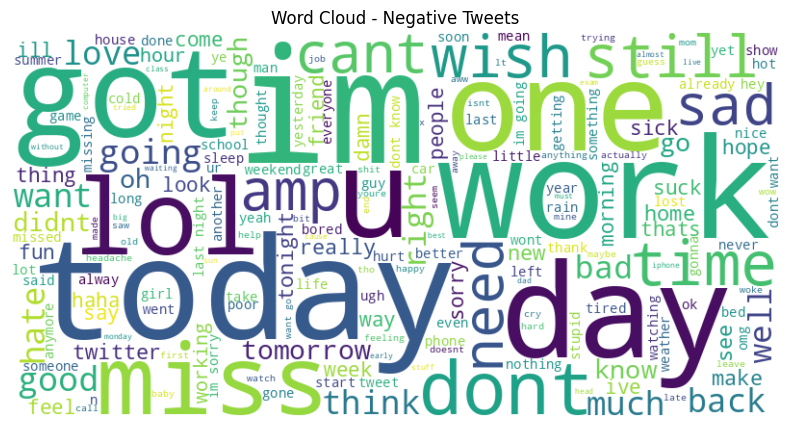

In [ ]:
negative_text = " ".join(df_sample[df_sample['sentiment'] == 'negative']['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Negative Tweets")
plt.show()

In [ ]:
def get_top_ngrams(text_data, ngram_range=(2,2), top_n=15):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(text_data)
    counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({'ngram': words, 'count': counts})
    return ngram_df.sort_values(by='count', ascending=False).head(top_n)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(text_data, ngram_range=(2,2), top_n=15):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(text_data)

    counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({'ngram': words, 'count': counts})
    return ngram_df.sort_values(by='count', ascending=False).head(top_n)

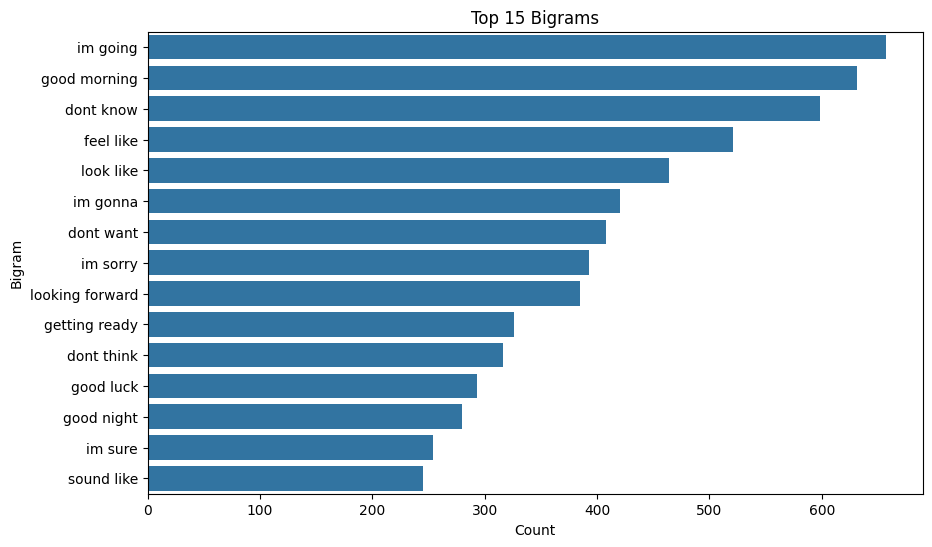

In [ ]:
top_bigrams = get_top_ngrams(df_sample['clean_text'], ngram_range=(2,2), top_n=15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_bigrams, y='ngram', x='count')
plt.title("Top 15 Bigrams")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80000,)
(20000,)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Sentiment Classification

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='positive')
    recall = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.76910,0.759449,0.7877,0.773316
1,Naive Bayes,0.75425,0.759359,0.7444,0.751805
2,Linear SVM,0.76080,0.749474,0.7835,0.766109


In [ ]:
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=10, scoring='f1_macro')
    print(model_name)
    print("Cross-validation scores:", np.round(cv_scores, 3))
    print("Mean CV F1-score:", np.round(cv_scores.mean(), 3))
    print("Standard Deviation:", np.round(cv_scores.std(), 3))
    print("-" * 50)

Logistic Regression
Cross-validation scores: [0.775 0.768 0.767 0.77  0.765 0.762 0.77  0.773 0.764 0.773]
Mean CV F1-score: 0.769
Standard Deviation: 0.004
--------------------------------------------------
Naive Bayes
Cross-validation scores: [0.758 0.752 0.748 0.754 0.753 0.749 0.756 0.761 0.749 0.76 ]
Mean CV F1-score: 0.754
Standard Deviation: 0.005
--------------------------------------------------
Linear SVM
Cross-validation scores: [0.762 0.752 0.756 0.758 0.757 0.754 0.757 0.764 0.749 0.756]
Mean CV F1-score: 0.756
Standard Deviation: 0.004
--------------------------------------------------


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.1}
Best CV Score: 0.7664579711036053


In [ ]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, pos_label='positive'))
print("Recall:", recall_score(y_test, y_pred_best, pos_label='positive'))
print("F1-score:", f1_score(y_test, y_pred_best, pos_label='positive'))

Accuracy: 0.7684
Precision: 0.7566947207345065
Recall: 0.7912
F1-score: 0.7735627688697693


Evaluation and Reporting


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

    negative       0.78      0.75      0.76     10000
    positive       0.76      0.79      0.77     10000

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



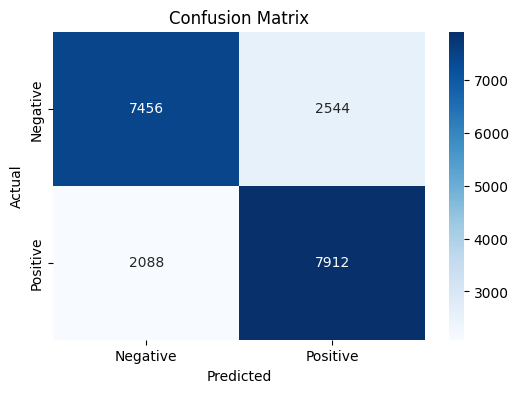

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
results_df = results_df.sort_values(by="F1-score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.76910,0.759449,0.7877,0.773316
2,Linear SVM,0.76080,0.749474,0.7835,0.766109
1,Naive Bayes,0.75425,0.759359,0.7444,0.751805


In this question, the Sentiment140 dataset was used, which is a large real-world Twitter dataset containing positive and negative sentiment labels. Although the assignment prefers datasets with positive, negative, and neutral labels, it allows a well-justified binary dataset, making this selection appropriate. The dataset is balanced, with equal numbers of positive and negative tweets, so no class imbalance handling was required. During preprocessing, the text data was cleaned by removing URLs, mentions, hashtags, punctuation, and special characters, followed by stopword removal and lemmatization. Exploratory Data Analysis (EDA) included class distribution visualization, sentence-length analysis, word clouds, and bigram analysis, which helped uncover patterns and commonly used terms in both positive and negative sentiments.

For sentiment classification, three traditional machine learning models—Logistic Regression, Naive Bayes, and Linear SVM—were trained using TF-IDF features. The models were evaluated using Accuracy, Precision, Recall, and F1-score. Based on the results, Logistic Regression performed the best, achieving the highest F1-score and providing a strong balance between precision and recall. Linear SVM also performed very closely, showing strong performance but slightly lower F1-score, while Naive Bayes performed comparatively lower due to its simplifying assumptions about feature independence. Overall, Logistic Regression proved to be the most effective model for this task, demonstrating that linear models work very well with high-dimensional TF-IDF features in text classification problems.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving stsa-test.txt to stsa-test (1).txt
Saving stsa-train.txt to stsa-train (1).txt


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def load_stsa_file(file_path):
    labels = []
    reviews = []

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            label = int(line[0])
            review = line[2:]

            labels.append(label)
            reviews.append(review)

    return pd.DataFrame({
        "sentiment": labels,
        "review": reviews
    })

train_df = load_stsa_file("stsa-train.txt")
test_df = load_stsa_file("stsa-test.txt")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

train_df.head()

Training dataset shape: (6920, 2)
Testing dataset shape: (1821, 2)


,sentiment,review
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


In [ ]:
print("Training Data Info")
print(train_df.info())

print("\nTesting Data Info")
print(test_df.info())

print("\nMissing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

print("\nTraining sentiment distribution:")
print(train_df["sentiment"].value_counts())

print("\nTesting sentiment distribution:")
print(test_df["sentiment"].value_counts())

Training Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6920 entries, 0 to 6919
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  6920 non-null   int64 
 1   review     6920 non-null   object
dtypes: int64(1), object(1)
memory usage: 108.3+ KB
None

Testing Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  1821 non-null   int64 
 1   review     1821 non-null   object
dtypes: int64(1), object(1)
memory usage: 28.6+ KB
None

Missing values in training data:
sentiment    0
review       0
dtype: int64

Missing values in testing data:
sentiment    0
review       0
dtype: int64

Training sentiment distribution:
sentiment
1    3610
0    3310
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
0    912
1    909
Name: count, dtype: i

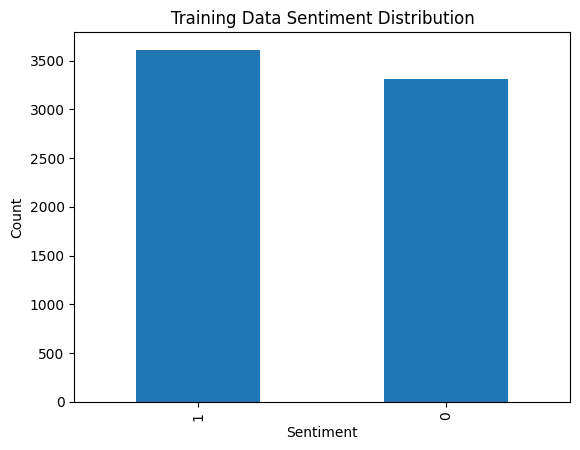

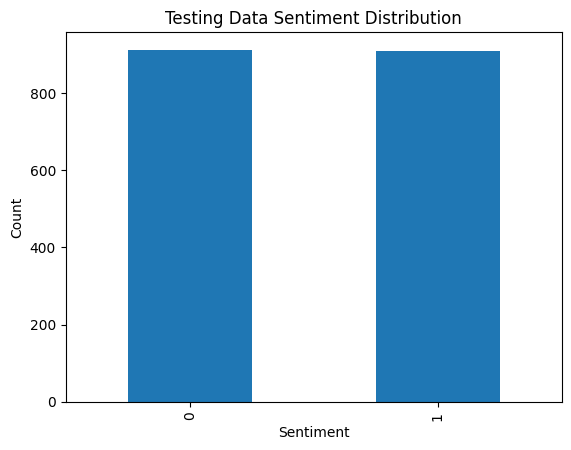

In [ ]:
train_df["sentiment"].value_counts().plot(kind="bar")
plt.title("Training Data Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

test_df["sentiment"].value_counts().plot(kind="bar")
plt.title("Testing Data Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Training word count summary:
count    6920.000000
mean       19.299855
std         9.318495
min         2.000000
25%        12.000000
50%        19.000000
75%        25.000000
max        52.000000
Name: word_count, dtype: float64

Testing word count summary:
count    1821.000000
mean       19.232839
std         8.922846
min         2.000000
25%        12.000000
50%        18.000000
75%        25.000000
max        56.000000
Name: word_count, dtype: float64


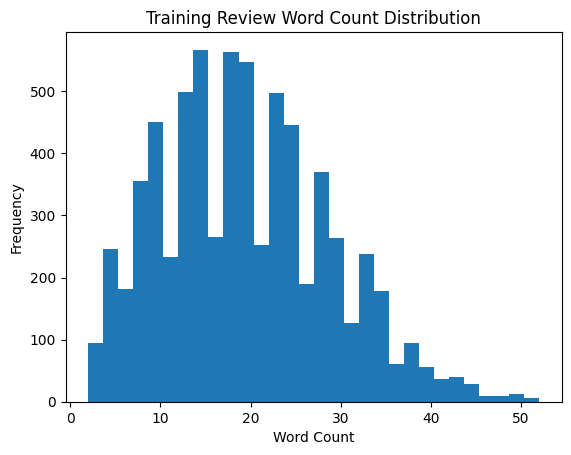

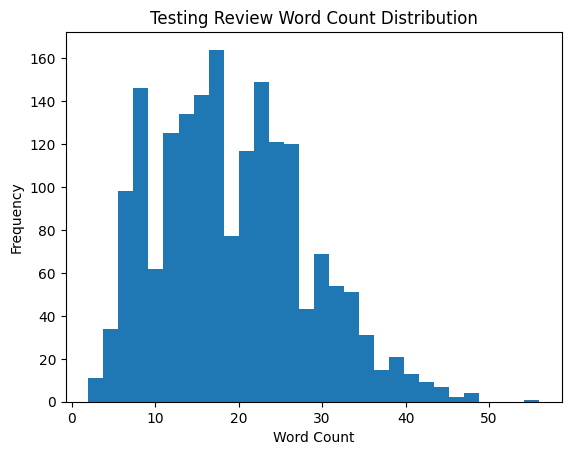

In [ ]:
train_df["word_count"] = train_df["review"].apply(lambda x: len(x.split()))
test_df["word_count"] = test_df["review"].apply(lambda x: len(x.split()))

print("Training word count summary:")
print(train_df["word_count"].describe())

print("\nTesting word count summary:")
print(test_df["word_count"].describe())

train_df["word_count"].plot(kind="hist", bins=30)
plt.title("Training Review Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

test_df["word_count"].plot(kind="hist", bins=30)
plt.title("Testing Review Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_review"] = train_df["review"].apply(clean_text)
test_df["clean_review"] = test_df["review"].apply(clean_text)

train_df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,"a stirring , funny and finally transporting re...",a stirring funny and finally transporting reim...,1
1,apparently reassembled from the cutting-room f...,apparently reassembled from the cuttingroom fl...,0
2,they presume their audience wo n't sit still f...,they presume their audience wo nt sit still fo...,0
3,this is a visually stunning rumination on love...,this is a visually stunning rumination on love...,1
4,jonathan parker 's bartleby should have been t...,jonathan parker s bartleby should have been th...,1


In [ ]:
X = train_df["clean_review"]
y = train_df["sentiment"]

X_test_text = test_df["clean_review"]
y_test = test_df["sentiment"]

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("80% Training split:", X_train_text.shape)
print("20% Validation split:", X_val_text.shape)
print("Final test data:", X_test_text.shape)

80% Training split: (5536,)
20% Validation split: (1384,)
Final test data: (1821,)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF training shape: (5536, 5000)
TF-IDF validation shape: (1384, 5000)
TF-IDF test shape: (1821, 5000)


10-fold cross-validation function

In [ ]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

def perform_cross_validation(model, X_train, y_train, model_name):
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    print("\n10-Fold Cross-Validation for", model_name)
    print("Scores:", np.round(cv_scores, 4))
    print("Mean Accuracy:", round(cv_scores.mean(), 4))
    print("Standard Deviation:", round(cv_scores.std(), 4))

In [ ]:
results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\nModel:", model_name)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    if "Test" in model_name:
        results.append({
            "Model": model_name.replace(" Test", ""),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        })

SVM

In [ ]:
svm_model = LinearSVC()

perform_cross_validation(svm_model, X_train_tfidf, y_train, "SVM")

svm_model.fit(X_train_tfidf, y_train)

svm_val_pred = svm_model.predict(X_val_tfidf)
evaluate_model("SVM Validation", y_val, svm_val_pred)

svm_test_pred = svm_model.predict(X_test_tfidf)
evaluate_model("SVM Test", y_test, svm_test_pred)


10-Fold Cross-Validation for SVM
Scores: [0.7671 0.7671 0.7383 0.7545 0.7708 0.7599 0.7342 0.7523 0.7378 0.7486]
Mean Accuracy: 0.7531
Standard Deviation: 0.0126

Model: SVM Validation
Accuracy: 0.7471
Precision: 0.748
Recall: 0.777
F1-score: 0.7622

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       662
           1       0.75      0.78      0.76       722

    accuracy                           0.75      1384
   macro avg       0.75      0.75      0.75      1384
weighted avg       0.75      0.75      0.75      1384

Confusion Matrix:
[[473 189]
 [161 561]]

Model: SVM Test
Accuracy: 0.7688
Precision: 0.7568
Recall: 0.791
F1-score: 0.7735

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       912
           1       0.76      0.79      0.77       909

    accuracy                           0.77      1821
   macro avg       0.77      0.7

KNN model

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

perform_cross_validation(knn_model, X_train_tfidf, y_train, "KNN")

knn_model.fit(X_train_tfidf, y_train)

knn_val_pred = knn_model.predict(X_val_tfidf)
evaluate_model("KNN Validation", y_val, knn_val_pred)

knn_test_pred = knn_model.predict(X_test_tfidf)
evaluate_model("KNN Test", y_test, knn_test_pred)


10-Fold Cross-Validation for KNN
Scores: [0.5036 0.5108 0.5271 0.4946 0.4982 0.4765 0.4973 0.4828 0.5479 0.4901]
Mean Accuracy: 0.5029
Standard Deviation: 0.0202

Model: KNN Validation
Accuracy: 0.5079
Precision: 0.5581
Recall: 0.2729
F1-score: 0.3665

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.76      0.60       662
           1       0.56      0.27      0.37       722

    accuracy                           0.51      1384
   macro avg       0.52      0.52      0.48      1384
weighted avg       0.53      0.51      0.48      1384

Confusion Matrix:
[[506 156]
 [525 197]]

Model: KNN Test
Accuracy: 0.5195
Precision: 0.5376
Recall: 0.2673
F1-score: 0.3571

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.77      0.62       912
           1       0.54      0.27      0.36       909

    accuracy                           0.52      1821
   macro avg       0.53      

Decision Tree model

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

perform_cross_validation(dt_model, X_train_tfidf, y_train, "Decision Tree")

dt_model.fit(X_train_tfidf, y_train)

dt_val_pred = dt_model.predict(X_val_tfidf)
evaluate_model("Decision Tree Validation", y_val, dt_val_pred)

dt_test_pred = dt_model.predict(X_test_tfidf)
evaluate_model("Decision Tree Test", y_test, dt_test_pred)


10-Fold Cross-Validation for Decision Tree
Scores: [0.6679 0.6823 0.6354 0.6336 0.6534 0.6354 0.6365 0.6564 0.6655 0.6673]
Mean Accuracy: 0.6534
Standard Deviation: 0.0165

Model: Decision Tree Validation
Accuracy: 0.6503
Precision: 0.6825
Recall: 0.6163
F1-score: 0.6477

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.69      0.65       662
           1       0.68      0.62      0.65       722

    accuracy                           0.65      1384
   macro avg       0.65      0.65      0.65      1384
weighted avg       0.65      0.65      0.65      1384

Confusion Matrix:
[[455 207]
 [277 445]]

Model: Decision Tree Test
Accuracy: 0.6793
Precision: 0.6914
Recall: 0.6458
F1-score: 0.6678

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       912
           1       0.69      0.65      0.67       909

    accuracy                           0.68      1821

Random Forest model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

perform_cross_validation(rf_model, X_train_tfidf, y_train, "Random Forest")

rf_model.fit(X_train_tfidf, y_train)

rf_val_pred = rf_model.predict(X_val_tfidf)
evaluate_model("Random Forest Validation", y_val, rf_val_pred)

rf_test_pred = rf_model.predict(X_test_tfidf)
evaluate_model("Random Forest Test", y_test, rf_test_pred)


10-Fold Cross-Validation for Random Forest
Scores: [0.7329 0.7473 0.7112 0.7202 0.7184 0.6823 0.6998 0.7161 0.7215 0.7233]
Mean Accuracy: 0.7173
Standard Deviation: 0.0167

Model: Random Forest Validation
Accuracy: 0.7124
Precision: 0.7314
Recall: 0.7091
F1-score: 0.7201

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       662
           1       0.73      0.71      0.72       722

    accuracy                           0.71      1384
   macro avg       0.71      0.71      0.71      1384
weighted avg       0.71      0.71      0.71      1384

Confusion Matrix:
[[474 188]
 [210 512]]

Model: Random Forest Test
Accuracy: 0.7353
Precision: 0.744
Recall: 0.7162
F1-score: 0.7298

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       912
           1       0.74      0.72      0.73       909

    accuracy                           0.74      1821


XGBoost model

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42
)

perform_cross_validation(xgb_model, X_train_tfidf, y_train, "XGBoost")

xgb_model.fit(X_train_tfidf, y_train)

xgb_val_pred = xgb_model.predict(X_val_tfidf)
evaluate_model("XGBoost Validation", y_val, xgb_val_pred)

xgb_test_pred = xgb_model.predict(X_test_tfidf)
evaluate_model("XGBoost Test", y_test, xgb_test_pred)


10-Fold Cross-Validation for XGBoost
Scores: [0.6588 0.6787 0.6354 0.657  0.6534 0.639  0.6365 0.6655 0.6637 0.6691]
Mean Accuracy: 0.6557
Standard Deviation: 0.0139

Model: XGBoost Validation
Accuracy: 0.6481
Precision: 0.6262
Recall: 0.8075
F1-score: 0.7054

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.47      0.56       662
           1       0.63      0.81      0.71       722

    accuracy                           0.65      1384
   macro avg       0.66      0.64      0.63      1384
weighted avg       0.66      0.65      0.64      1384

Confusion Matrix:
[[314 348]
 [139 583]]

Model: XGBoost Test
Accuracy: 0.6507
Precision: 0.612
Recall: 0.8207
F1-score: 0.7011

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.48      0.58       912
           1       0.61      0.82      0.70       909

    accuracy                           0.65      1821
   macro avg      

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.768808,0.756842,0.790979,0.773534
3,Random Forest,0.735310,0.744000,0.716172,0.729821
4,XGBoost,0.650741,0.611977,0.820682,0.701128
2,Decision Tree,0.679297,0.691402,0.645765,0.667804
1,KNN,0.519495,0.537611,0.267327,0.357090


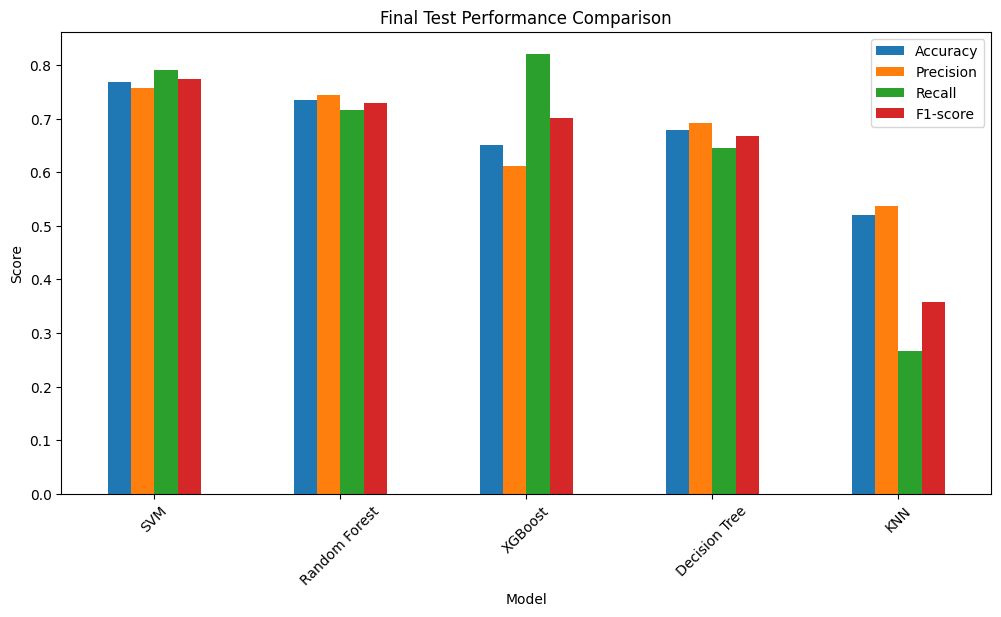

In [ ]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Test Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Best model based on test F1-score:")
print(best_model)

print(f"""
Conclusion:

The sentiment classification task was performed using multiple machine learning models including SVM, KNN, Decision Tree, Random Forest, and XGBoost. The original training dataset was split into 80% training data and 20% validation data. A TF-IDF vectorizer was fitted only on the training data to prevent data leakage. Each model was trained using the training split, and 10-fold cross-validation was applied on the training data to ensure model robustness.

Among all the models, {best_model['Model']} achieved the best performance on the test dataset with an F1-score of {best_model['F1-score']:.4f} and accuracy of {best_model['Accuracy']:.4f}. This indicates that it generalizes better to unseen data compared to the other models.

Random Forest and XGBoost also showed reasonable performance, while Decision Tree performed moderately. KNN showed the weakest performance, likely due to its sensitivity to high-dimensional sparse text features.

Overall, the results demonstrate that {best_model['Model']} is the most suitable model for this sentiment classification task. The final evaluation was conducted on the unseen test dataset using Accuracy, Precision, Recall, and F1-score, satisfying the assignment requirements.
""")

Best model based on test F1-score:
Model             SVM
Accuracy     0.768808
Precision    0.756842
Recall       0.790979
F1-score     0.773534
Name: 0, dtype: object

Conclusion:

The sentiment classification task was performed using multiple machine learning models including SVM, KNN, Decision Tree, Random Forest, and XGBoost. The original training dataset was split into 80% training data and 20% validation data. A TF-IDF vectorizer was fitted only on the training data to prevent data leakage. Each model was trained using the training split, and 10-fold cross-validation was applied on the training data to ensure model robustness.

Among all the models, SVM achieved the best performance on the test dataset with an F1-score of 0.7735 and accuracy of 0.7688. This indicates that it generalizes better to unseen data compared to the other models.

Random Forest and XGBoost also showed reasonable performance, while Decision Tree performed moderately. KNN showed the weakest performance, lik

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Amazon_Unlocked_Mobile.csv to Amazon_Unlocked_Mobile (1).csv


In [ ]:
df = pd.read_csv("Amazon_Unlocked_Mobile.csv")

print(df.shape)
df.head()

(413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [ ]:
print(df.info())
print(df.isnull().sum())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413840 entries, 0 to 413839
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Product Name  413840 non-null  object 
 1   Brand Name    348669 non-null  object 
 2   Price         407907 non-null  float64
 3   Rating        413840 non-null  int64  
 4   Reviews       413770 non-null  object 
 5   Review Votes  401544 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 18.9+ MB
None
Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64
Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')


In [ ]:
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

if len(date_columns) == 0:
    print("No date or time column is available in this dataset.")
    print("Therefore, date-based EDA is not applicable for Question 3.")
else:
    print("Date columns found:", date_columns)

No date or time column is available in this dataset.
Therefore, date-based EDA is not applicable for Question 3.


In [ ]:
df = df.dropna(subset=['Reviews'])

df['Reviews'] = df['Reviews'].astype(str)

# Use sample because full dataset is very large for clustering
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

print(df_sample.shape)
df_sample.head()

(5000, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,Nokia C3 (C3-00) WHITE Unlocked Phone,Nokia,59.95,2,I needed a texting phone that did not require ...,1.0
1,"Apple iPhone 6S Plus Unlocked Smartphone, 32 G...",Apple,749.99,5,Excellent!,0.0
2,Samsung Galaxy Note 3 N9005 Unlocked Cellphone...,Samsung,325.16,5,I recommend this excellent team for the many d...,0.0
3,BLU Dash L Unlocked Smartphone - Global GSM - ...,BLU,49.99,5,updated review. Purchased this phone on Novemb...,5.0
4,"LG G3 D855 Factory Unlocked Cellphone, Interna...",LG,195.99,3,battery fail,0.0


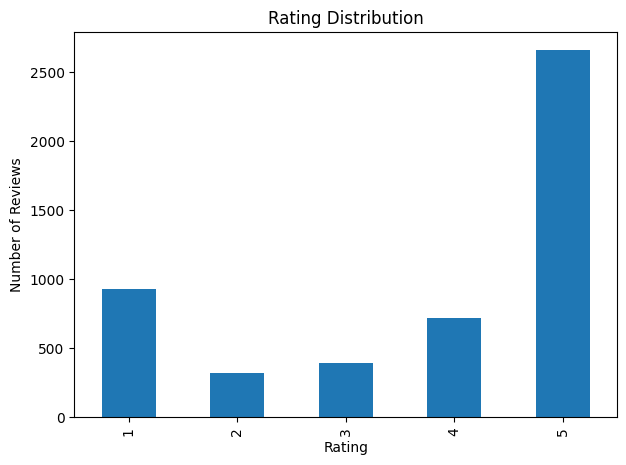

In [ ]:
plt.figure(figsize=(7,5))
df_sample['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

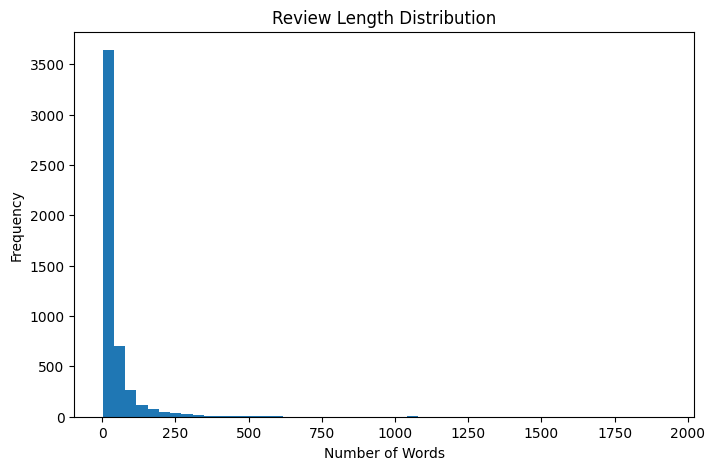

count    5000.000000
mean       42.255800
std        87.910475
min         1.000000
25%         5.000000
50%        18.000000
75%        43.000000
max      1926.000000
Name: review_length, dtype: float64


In [ ]:
df_sample['review_length'] = df_sample['Reviews'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df_sample['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print(df_sample['review_length'].describe())

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return " ".join(words)

df_sample['clean_reviews'] = df_sample['Reviews'].apply(clean_text)

df_sample[['Reviews', 'clean_reviews']].head()

,Reviews,clean_reviews
0,I needed a texting phone that did not require ...,needed texting phone require data plan also ne...
1,Excellent!,excellent
2,I recommend this excellent team for the many d...,recommend excellent team many differentiating ...
3,updated review. Purchased this phone on Novemb...,updated review purchased phone november worked...
4,battery fail,battery fail


In [ ]:
tfidf = TfidfVectorizer(max_features=1000)

X_tfidf = tfidf.fit_transform(df_sample['clean_reviews'])

print(X_tfidf.shape)

(5000, 1000)


Method 1 — K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_sample['kmeans_cluster'] = kmeans.fit_predict(X_tfidf)

print(df_sample['kmeans_cluster'].value_counts())

kmeans_score = silhouette_score(X_tfidf, df_sample['kmeans_cluster'])
print("K-Means Silhouette Score:", kmeans_score)

kmeans_cluster
3    4101
1     255
4     247
0     221
2     176
Name: count, dtype: int64
K-Means Silhouette Score: 0.049171315348917


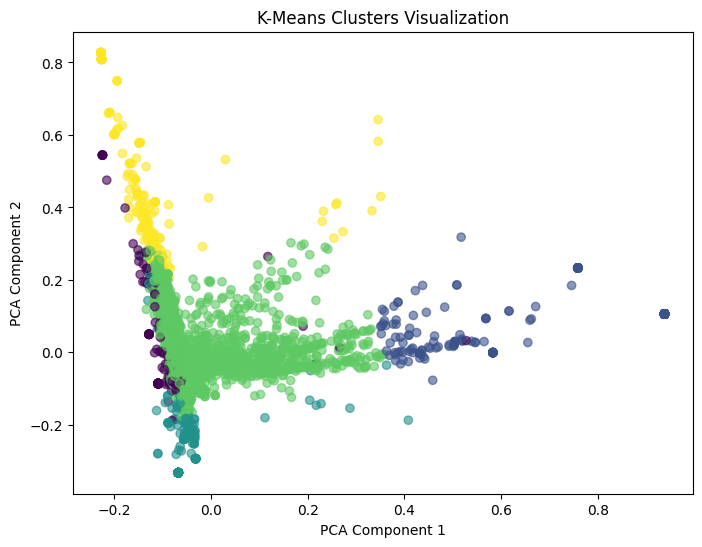

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_sample['kmeans_cluster'], alpha=0.6)
plt.title("K-Means Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Method 2 — DBSCAN Clustering

In [ ]:
X_scaled = StandardScaler().fit_transform(X_pca)

dbscan = DBSCAN(eps=0.5, min_samples=5)

df_sample['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df_sample['dbscan_cluster'].value_counts())

dbscan_cluster
 0    4752
 2     126
 1      90
 3      27
-1       5
Name: count, dtype: int64


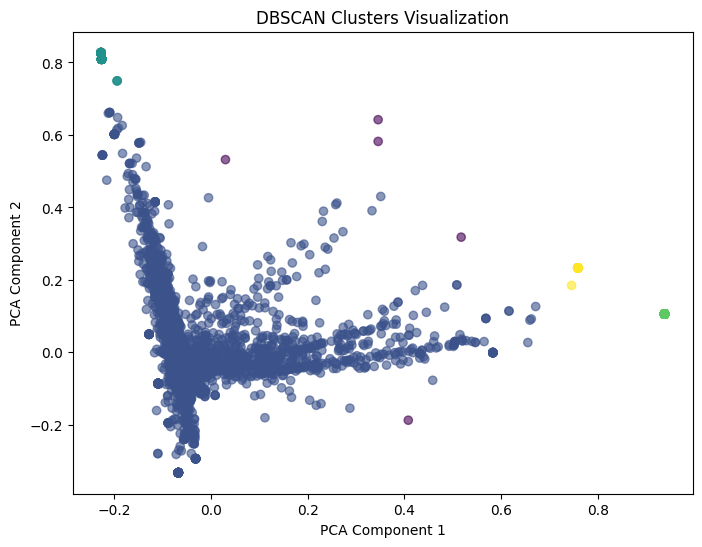

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_sample['dbscan_cluster'], alpha=0.6)
plt.title("DBSCAN Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Method 3 — Hierarchical Clustering

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=5)

df_sample['hierarchical_cluster'] = hierarchical.fit_predict(X_pca)

print(df_sample['hierarchical_cluster'].value_counts())

hierarchical_score = silhouette_score(X_pca, df_sample['hierarchical_cluster'])
print("Hierarchical Clustering Silhouette Score:", hierarchical_score)

hierarchical_cluster
1    3357
4     690
0     623
2     177
3     153
Name: count, dtype: int64
Hierarchical Clustering Silhouette Score: 0.6008366737335789


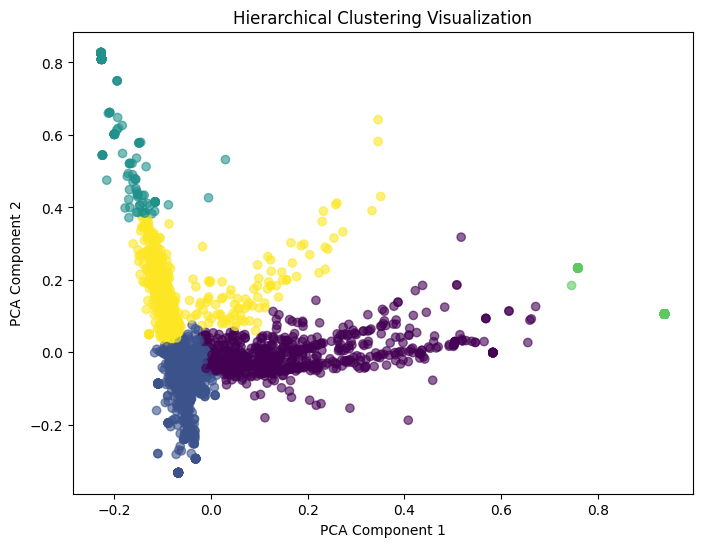

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_sample['hierarchical_cluster'], alpha=0.6)
plt.title("Hierarchical Clustering Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Method 4 — Word2Vec-Based Clustering

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.6 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

tokenized_reviews = df_sample['clean_reviews'].apply(lambda x: x.split())

w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

def review_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_w2v = np.array([review_vector(tokens) for tokens in tokenized_reviews])

print(X_w2v.shape)

(5000, 100)


In [ ]:
w2v_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_sample['word2vec_cluster'] = w2v_kmeans.fit_predict(X_w2v)

print(df_sample['word2vec_cluster'].value_counts())

w2v_score = silhouette_score(X_w2v, df_sample['word2vec_cluster'])
print("Word2Vec K-Means Silhouette Score:", w2v_score)

word2vec_cluster
4    1733
0    1532
2    1175
3     363
1     197
Name: count, dtype: int64
Word2Vec K-Means Silhouette Score: 0.4491830425564776


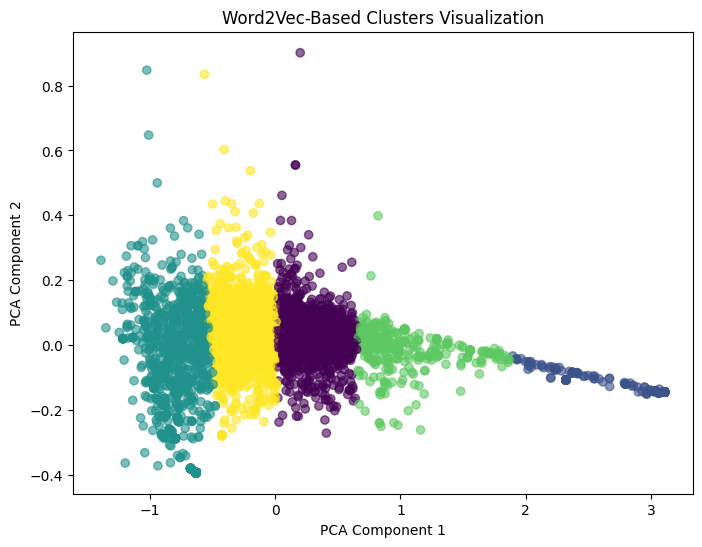

In [ ]:
X_w2v_pca = PCA(n_components=2, random_state=42).fit_transform(X_w2v)

plt.figure(figsize=(8,6))
plt.scatter(X_w2v_pca[:,0], X_w2v_pca[:,1], c=df_sample['word2vec_cluster'], alpha=0.6)
plt.title("Word2Vec-Based Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [ ]:
for cluster in sorted(df_sample['kmeans_cluster'].unique()):
    print("\nCluster:", cluster)
    sample_reviews = df_sample[df_sample['kmeans_cluster'] == cluster]['Reviews'].head(3)
    for review in sample_reviews:
        print("-", review[:300])


Cluster: 0
- So easy to use. Love it
- i love everything about this phone... size... speed... design...
- Great phone. love it.

Cluster: 1
- Very good, Thanks
- Its a good phone really i dont used too much but its work i get what i want and a good price too
- Very good

Cluster: 2
- Excellent!
- excellent product
- Excellent!! Love it

Cluster: 3
- I needed a texting phone that did not require a data plan. I also needed a Nokia as they have the best antenna and can get out when other cell phones can't. Buyer beware! This phone is very difficult to use. It locks after a few seconds of non-use and that can't be turned off! The screen goes dark a
- I recommend this excellent team for the many differentiating factors of competition, the screen, the durability of the battery, the S Pen and among others soprendido let me!
- updated review. Purchased this phone on November 27, 2015. Worked great for 5 months. It started to not keep track of time last week. Now it doesn't charge. I DO NOT RE

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

K-Means clustering produced highly imbalanced clusters with one dominant group and achieved a very low Silhouette Score ~0.049, indicating poor separation of text data when using TF-IDF features. DBSCAN also performed poorly, as it grouped most data points into a single cluster and identified very few meaningful clusters, showing that density-based methods struggle with high-dimensional sparse text data. In contrast, Hierarchical clustering performed the best, achieving a high Silhouette Score 0.601 and generating more balanced and well-separated clusters, making it the most effective method for this dataset. Word2Vec-based clustering also showed strong performance with a Silhouette Score of ~0.449, as it captures semantic relationships between words rather than relying only on frequency-based features like TF-IDF. Overall, Hierarchical clustering provided the best clustering quality, followed by Word2Vec-based clustering, while K-Means and DBSCAN were less effective for this text clustering task.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

